# Fase 2 — CNN con Transfer Learning (ResNet-50)
## Proyecto Final IA · EAFIT 2026-1

**Prerequisito:** Haber ejecutado `fase1_eda_plantvillage.ipynb` al menos una vez.
Los artefactos deben estar en **Google Drive/IA_EAFIT/**.

> **Si la sesión expiró:** ejecuta solo la sección 0 (Drive + restaurar) y continúa donde quedaste.
> El modelo se guarda en Drive automáticamente cada época que mejora.

---


## 0. Setup — Drive, dependencias y restauración de Fase 1

### 0.1 Montar Google Drive y restaurar artefactos de Fase 1

Monta Drive, define las funciones `save_to_drive` / `load_from_drive`, y restaura
el `config_fase1.json` y el `dataset_split` que generó la Fase 1.
Si la sesión expiró a mitad del entrenamiento, esta celda también restaura los pesos del mejor modelo.

In [1]:
from google.colab import drive
from pathlib import Path
import os, shutil, json, zipfile

drive.mount('/content/drive')

# ── Rutas ──────────────────────────────────────────────────────────────────
DRIVE_DIR       = Path('/content/drive/MyDrive/IA_EAFIT')
DRIVE_ARTIFACTS = DRIVE_DIR / 'artifacts'
DRIVE_FIGURES   = DRIVE_DIR / 'figures'
DRIVE_DATASET   = DRIVE_DIR / 'dataset'

ARTIFACTS = Path('/content/artifacts')
ARTIFACTS.mkdir(exist_ok=True)

# ── Funciones auxiliares ────────────────────────────────────────────────────
def save_to_drive(local_path, subfolder='artifacts', verbose=True):
    local_path = Path(local_path)
    if not local_path.exists():
        if verbose: print(f'  ⚠️  No encontrado: {local_path}')
        return None
    dest = DRIVE_DIR / subfolder / local_path.name
    (DRIVE_DIR / subfolder).mkdir(exist_ok=True)
    shutil.copy2(local_path, dest)
    if verbose:
        print(f'  ✅ {local_path.name:40s} → Drive/{subfolder}/ ({dest.stat().st_size/1024:.1f} KB)')
    return dest

def load_from_drive(filename, subfolder='artifacts', dest_dir='/content/artifacts'):
    src = DRIVE_DIR / subfolder / filename
    if not src.exists():
        print(f'  ⚠️  No encontrado en Drive: {src}')
        return None
    dest = Path(dest_dir); dest.mkdir(parents=True, exist_ok=True)
    dest_file = dest / filename
    shutil.copy2(src, dest_file)
    print(f'  ✅ {filename} ← Drive/{subfolder}/')
    return dest_file

# ── Restaurar config de Fase 1 ─────────────────────────────────────────────
print('Restaurando artefactos de Fase 1 desde Drive...')
load_from_drive('config_fase1.json', 'artifacts')

# ── Restaurar dataset_split (solo si no existe ya en /content/) ────────────
SPLIT_DIR = Path('/content/dataset_split')
if not SPLIT_DIR.exists() or not any(SPLIT_DIR.rglob('*.jpg')):
    zip_local = ARTIFACTS / 'dataset_split.zip'
    print('Restaurando dataset_split desde Drive (puede tardar ~1 min)...')
    load_from_drive('dataset_split.zip', 'dataset', '/content/artifacts')
    print('  Descomprimiendo...')
    with zipfile.ZipFile(zip_local, 'r') as zf:
        zf.extractall('/content')
    print(f'  ✅ dataset_split restaurado en {SPLIT_DIR}')
else:
    print(f'  ✅ dataset_split ya existe en {SPLIT_DIR}')

# ── Restaurar modelo previo si la sesión expiró a mitad ─────────────────────
model_local = ARTIFACTS / 'best_resnet50.pth'
if not model_local.exists():
    result = load_from_drive('best_resnet50.pth', 'artifacts')
    if result:
        print('  ✅ Pesos restaurados — puedes cargarlos con model.load_state_dict(torch.load(MODEL_PATH))')
    else:
        print('  ℹ️  Sin modelo previo — se entrenará desde cero')
else:
    print(f'  ✅ Modelo ya existe localmente')

print()
print('✅ Drive montado y artefactos restaurados')


Mounted at /content/drive
Restaurando artefactos de Fase 1 desde Drive...
  ✅ config_fase1.json ← Drive/artifacts/
Restaurando dataset_split desde Drive (puede tardar ~1 min)...
  ✅ dataset_split.zip ← Drive/dataset/
  Descomprimiendo...
  ✅ dataset_split restaurado en /content/dataset_split
  ⚠️  No encontrado en Drive: /content/drive/MyDrive/IA_EAFIT/artifacts/best_resnet50.pth
  ℹ️  Sin modelo previo — se entrenará desde cero

✅ Drive montado y artefactos restaurados


In [2]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn tqdm
print('✅ Dependencias listas')

✅ Dependencias listas


In [3]:
import json, time, copy
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score
)

# ── Reproducibilidad ────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ──────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Cargar config de Fase 1 ─────────────────────────────────────────────────
ARTIFACTS = Path('/content/artifacts')
ARTIFACTS.mkdir(exist_ok=True)

CONFIG_PATH = ARTIFACTS / 'config_fase1.json'
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f:
        cfg = json.load(f)
    SPLIT_DIR    = Path(cfg['split_dir'])
    CLASS_NAMES  = cfg['class_names']
    IMG_SIZE     = cfg['img_size']
    BATCH_SIZE   = cfg['batch_size']
    IMAGENET_MEAN = cfg['imagenet_mean']
    IMAGENET_STD  = cfg['imagenet_std']
    N_CLASSES    = cfg['n_clases']
    print(f'\n✅ Config cargada desde Fase 1')
    print(f'   Clases     : {N_CLASSES}')
    print(f'   IMG_SIZE   : {IMG_SIZE}')
    print(f'   BATCH_SIZE : {BATCH_SIZE}')
else:
    # Fallback: valores por defecto si se corre esta fase de forma independiente
    print('⚠️  config_fase1.json no encontrado — usando valores por defecto')
    SPLIT_DIR     = Path('/content/dataset_split')
    IMG_SIZE      = 224
    BATCH_SIZE    = 32
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]
    # Inferir clases del directorio
    CLASS_NAMES   = sorted([d.name for d in (SPLIT_DIR / 'train').iterdir() if d.is_dir()])
    N_CLASSES     = len(CLASS_NAMES)
    print(f'   Clases inferidas: {N_CLASSES}')

Device: cuda
GPU: Tesla T4
VRAM disponible: 15.6 GB

✅ Config cargada desde Fase 1
   Clases     : 6
   IMG_SIZE   : 224
   BATCH_SIZE : 32


## 1. DataLoaders

In [4]:
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

ds_train = datasets.ImageFolder(SPLIT_DIR / 'train', transform=transform_train)
ds_val   = datasets.ImageFolder(SPLIT_DIR / 'val',   transform=transform_eval)
ds_test  = datasets.ImageFolder(SPLIT_DIR / 'test',  transform=transform_eval)

NUM_WORKERS = 2
loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
loader_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
loader_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

CLASS_NAMES = ds_train.classes
IDX_TO_CLASS = {v: k for k, v in ds_train.class_to_idx.items()}

print(f'Train: {len(ds_train):,} imágenes | {len(loader_train)} batches')
print(f'Val  : {len(ds_val):,} imágenes  | {len(loader_val)} batches')
print(f'Test : {len(ds_test):,} imágenes  | {len(loader_test)} batches')

Train: 4,986 imágenes | 156 batches
Val  : 1,066 imágenes  | 34 batches
Test : 1,075 imágenes  | 34 batches


## 2. Arquitectura — ResNet-50 con Fine-Tuning

**Estrategia de transfer learning:**
- **Fase A (épocas 1–10):** congelar todas las capas base, entrenar solo el clasificador (FC layer). Learning rate alto.
- **Fase B (épocas 11–20):** descongelar la capa `layer4` de ResNet para fine-tuning profundo. Learning rate bajo.

Esta estrategia es más estable y converge mejor que descongelar todo desde el inicio.

In [5]:
def build_resnet50(n_classes: int, freeze_base: bool = True) -> nn.Module:
    """
    Construye ResNet-50 preentrenado con cabeza de clasificación personalizada.

    Args:
        n_classes:    Número de clases de salida.
        freeze_base:  Si True, congela todas las capas excepto la FC.
    Returns:
        Modelo listo para entrenar.
    """
    # Cargar ResNet-50 con pesos ImageNet
    weights = models.ResNet50_Weights.IMAGENET1K_V2
    model = models.resnet50(weights=weights)

    # Congelar todas las capas base
    if freeze_base:
        for param in model.parameters():
            param.requires_grad = False

    # Reemplazar la capa FC (in_features=2048 en ResNet-50)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.4),
        nn.Linear(512, n_classes)
    )
    return model


def unfreeze_layer4(model: nn.Module) -> None:
    """Descongela layer4 + avgpool + fc para fine-tuning profundo."""
    for name, param in model.named_parameters():
        if any(layer in name for layer in ['layer4', 'avgpool', 'fc']):
            param.requires_grad = True


def count_params(model: nn.Module) -> dict:
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {'total': total, 'trainable': trainable, 'frozen': total - trainable}


# Construir modelo
model = build_resnet50(n_classes=N_CLASSES, freeze_base=True)
model = model.to(DEVICE)

params = count_params(model)
print('ResNet-50 — Transfer Learning')
print(f'  Parámetros totales    : {params["total"]:,}')
print(f'  Parámetros entrenables: {params["trainable"]:,}  ({100*params["trainable"]/params["total"]:.1f}%)')
print(f'  Parámetros congelados : {params["frozen"]:,}')
print(f'\nCabeza clasificadora:')
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


ResNet-50 — Transfer Learning
  Parámetros totales    : 24,560,198
  Parámetros entrenables: 1,052,166  (4.3%)
  Parámetros congelados : 23,508,032

Cabeza clasificadora:
Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=512, out_features=6, bias=True)
)


## 3. Configuración del entrenamiento

In [6]:
# ── Hiperparámetros ─────────────────────────────────────────────────────────
EPOCHS_FASE_A = 10   # Solo FC congelada
EPOCHS_FASE_B = 10   # Fine-tuning layer4
EPOCHS_TOTAL  = EPOCHS_FASE_A + EPOCHS_FASE_B

LR_FASE_A = 1e-3     # Learning rate para la cabeza clasificadora
LR_FASE_B = 1e-4     # LR más bajo para fine-tuning
WEIGHT_DECAY = 1e-4  # Regularización L2

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing mejora generalización

# Optimizador inicial: solo parámetros de la FC
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_FASE_A,
    weight_decay=WEIGHT_DECAY
)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

print('Configuración de entrenamiento:')
print(f'  Épocas Fase A (solo FC)    : {EPOCHS_FASE_A}')
print(f'  Épocas Fase B (+ layer4)   : {EPOCHS_FASE_B}')
print(f'  Total épocas               : {EPOCHS_TOTAL}')
print(f'  LR Fase A                  : {LR_FASE_A}')
print(f'  LR Fase B                  : {LR_FASE_B}')
print(f'  Weight decay               : {WEIGHT_DECAY}')
print(f'  Loss                       : CrossEntropyLoss (label_smoothing=0.1)')
print(f'  Scheduler                  : StepLR (step=5, gamma=0.5)')

Configuración de entrenamiento:
  Épocas Fase A (solo FC)    : 10
  Épocas Fase B (+ layer4)   : 10
  Total épocas               : 20
  LR Fase A                  : 0.001
  LR Fase B                  : 0.0001
  Weight decay               : 0.0001
  Loss                       : CrossEntropyLoss (label_smoothing=0.1)
  Scheduler                  : StepLR (step=5, gamma=0.5)


## 4. Loop de entrenamiento

In [7]:
def run_epoch(model, loader, criterion, optimizer=None, phase='train'):
    """
    Ejecuta una época completa de entrenamiento o validación.

    Args:
        model:     Modelo PyTorch.
        loader:    DataLoader.
        criterion: Función de pérdida.
        optimizer: Si None, solo hace inferencia (val/test).
        phase:     'train' o 'val'.
    Returns:
        epoch_loss, epoch_acc
    """
    is_train = (phase == 'train')
    model.train() if is_train else model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += imgs.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


# ── Historial de métricas ────────────────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'lr': []
}
best_val_acc  = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
PATIENCE = 5
no_improve = 0

MODEL_PATH = ARTIFACTS / 'best_resnet50.pth'

print('Iniciando entrenamiento...')
print('=' * 70)

for epoch in range(1, EPOCHS_TOTAL + 1):

    # ── Transición a Fase B ──────────────────────────────────────────────────
    if epoch == EPOCHS_FASE_A + 1:
        print('\n' + '─' * 70)
        print(f'  FASE B: descongelando layer4 — LR → {LR_FASE_B}')
        print('─' * 70)
        unfreeze_layer4(model)
        params_b = count_params(model)
        print(f'  Parámetros entrenables ahora: {params_b["trainable"]:,}')
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=LR_FASE_B,
            weight_decay=WEIGHT_DECAY
        )
        scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

    t0 = time.time()
    train_loss, train_acc = run_epoch(model, loader_train, criterion, optimizer, 'train')
    val_loss,   val_acc   = run_epoch(model, loader_val,   criterion, None,      'val')
    scheduler.step()
    elapsed = time.time() - t0

    current_lr = scheduler.get_last_lr()[0]
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    fase = 'A' if epoch <= EPOCHS_FASE_A else 'B'
    marker = ''

    # Early stopping y checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, MODEL_PATH)
        save_to_drive(MODEL_PATH, subfolder='artifacts', verbose=False)  # backup automático en Drive
        no_improve = 0
        marker = ' ✅ MEJOR'
    else:
        no_improve += 1

    print(f'[{fase}] Epoch {epoch:02d}/{EPOCHS_TOTAL} '
          f'| Loss: {train_loss:.4f}/{val_loss:.4f} '
          f'| Acc: {train_acc:.4f}/{val_acc:.4f} '
          f'| LR: {current_lr:.2e} '
          f'| {elapsed:.0f}s{marker}')

    if no_improve >= PATIENCE and epoch > EPOCHS_FASE_A:
        print(f'\n⏹  Early stopping en época {epoch} (sin mejora por {PATIENCE} épocas)')
        break

print('\n' + '=' * 70)
print(f'Entrenamiento finalizado.')
print(f'Mejor val_acc: {best_val_acc:.4f}')
print(f'Modelo guardado en: {MODEL_PATH}')

Iniciando entrenamiento...
[A] Epoch 01/20 | Loss: 0.7589/0.6337 | Acc: 0.8748/0.9437 | LR: 1.00e-03 | 43s ✅ MEJOR
[A] Epoch 02/20 | Loss: 0.5991/0.5687 | Acc: 0.9483/0.9559 | LR: 1.00e-03 | 44s ✅ MEJOR
[A] Epoch 03/20 | Loss: 0.5705/0.5486 | Acc: 0.9599/0.9672 | LR: 1.00e-03 | 42s ✅ MEJOR
[A] Epoch 04/20 | Loss: 0.5568/0.5556 | Acc: 0.9639/0.9681 | LR: 1.00e-03 | 42s ✅ MEJOR
[A] Epoch 05/20 | Loss: 0.5507/0.5514 | Acc: 0.9647/0.9634 | LR: 5.00e-04 | 42s
[A] Epoch 06/20 | Loss: 0.5343/0.5484 | Acc: 0.9697/0.9597 | LR: 5.00e-04 | 44s
[A] Epoch 07/20 | Loss: 0.5268/0.5469 | Acc: 0.9757/0.9559 | LR: 5.00e-04 | 43s
[A] Epoch 08/20 | Loss: 0.5222/0.5376 | Acc: 0.9765/0.9653 | LR: 5.00e-04 | 44s
[A] Epoch 09/20 | Loss: 0.5183/0.5286 | Acc: 0.9805/0.9644 | LR: 5.00e-04 | 43s
[A] Epoch 10/20 | Loss: 0.5175/0.5247 | Acc: 0.9787/0.9747 | LR: 2.50e-04 | 43s ✅ MEJOR

──────────────────────────────────────────────────────────────────────
  FASE B: descongelando layer4 — LR → 0.0001
────────────────

## 5. Curvas de entrenamiento (P1)

In [8]:
epochs_ran = len(history['train_loss'])
xs = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Curvas de entrenamiento — ResNet-50 PlantVillage', fontsize=13, fontweight='bold')

# Separador Fase A / Fase B
for ax in axes:
    if EPOCHS_FASE_A < epochs_ran:
        ax.axvline(EPOCHS_FASE_A + 0.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
        ax.text(EPOCHS_FASE_A + 0.7, ax.get_ylim()[0], 'Fase B', fontsize=8, color='gray')

# Pérdida
axes[0].plot(xs, history['train_loss'], label='Train', color='royalblue', linewidth=2)
axes[0].plot(xs, history['val_loss'],   label='Val',   color='tomato',    linewidth=2)
axes[0].set_title('Pérdida (CrossEntropy)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(xs, history['train_acc'], label='Train', color='royalblue', linewidth=2)
axes[1].plot(xs, history['val_acc'],   label='Val',   color='tomato',    linewidth=2)
axes[1].axhline(best_val_acc, color='green', linestyle='--', linewidth=1,
                label=f'Best val: {best_val_acc:.4f}')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1.05])
axes[1].legend()
axes[1].grid(alpha=0.3)

# Learning rate
axes[2].plot(xs, history['lr'], color='darkorange', linewidth=2, marker='o', markersize=4)
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('LR')
axes[2].set_yscale('log')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/fig5_curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura guardada: fig5_curvas_entrenamiento.png')

/tmp/ipykernel_2588/3137058856.py:42: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


✅ Figura guardada: fig5_curvas_entrenamiento.png


## 6. Evaluación en Test Set

In [9]:
# Cargar mejor modelo guardado
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for imgs, labels in loader_test:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Métricas
acc   = accuracy_score(all_labels, all_preds)
f1    = f1_score(all_labels, all_preds, average='macro')
f1_w  = f1_score(all_labels, all_preds, average='weighted')
try:
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
except Exception:
    auc = float('nan')

print('=' * 50)
print('  MÉTRICAS EN TEST SET')
print('=' * 50)
print(f'  Accuracy        : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  F1-macro        : {f1:.4f}')
print(f'  F1-weighted     : {f1_w:.4f}')
print(f'  AUC-ROC (macro) : {auc:.4f}')
print('=' * 50)

# Reporte por clase
print('\nReporte por clase:')
labels_cortas = [c.replace('___', '\n')[:30] for c in CLASS_NAMES]
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=3))

  MÉTRICAS EN TEST SET
  Accuracy        : 0.9981  (99.81%)
  F1-macro        : 0.9952
  F1-weighted     : 0.9981
  AUC-ROC (macro) : 1.0000

Reporte por clase:
                               precision    recall  f1-score   support

Pepper__bell___Bacterial_spot      1.000     1.000     1.000       151
       Pepper__bell___healthy      1.000     1.000     1.000       223
         Potato___Late_blight      0.993     0.993     0.993       150
             Potato___healthy      0.960     1.000     0.980        24
           Tomato_Late_blight      1.000     0.997     0.998       287
               Tomato_healthy      1.000     1.000     1.000       240

                     accuracy                          0.998      1075
                    macro avg      0.992     0.998     0.995      1075
                 weighted avg      0.998     0.998     0.998      1075



### 6.1 Matriz de confusión

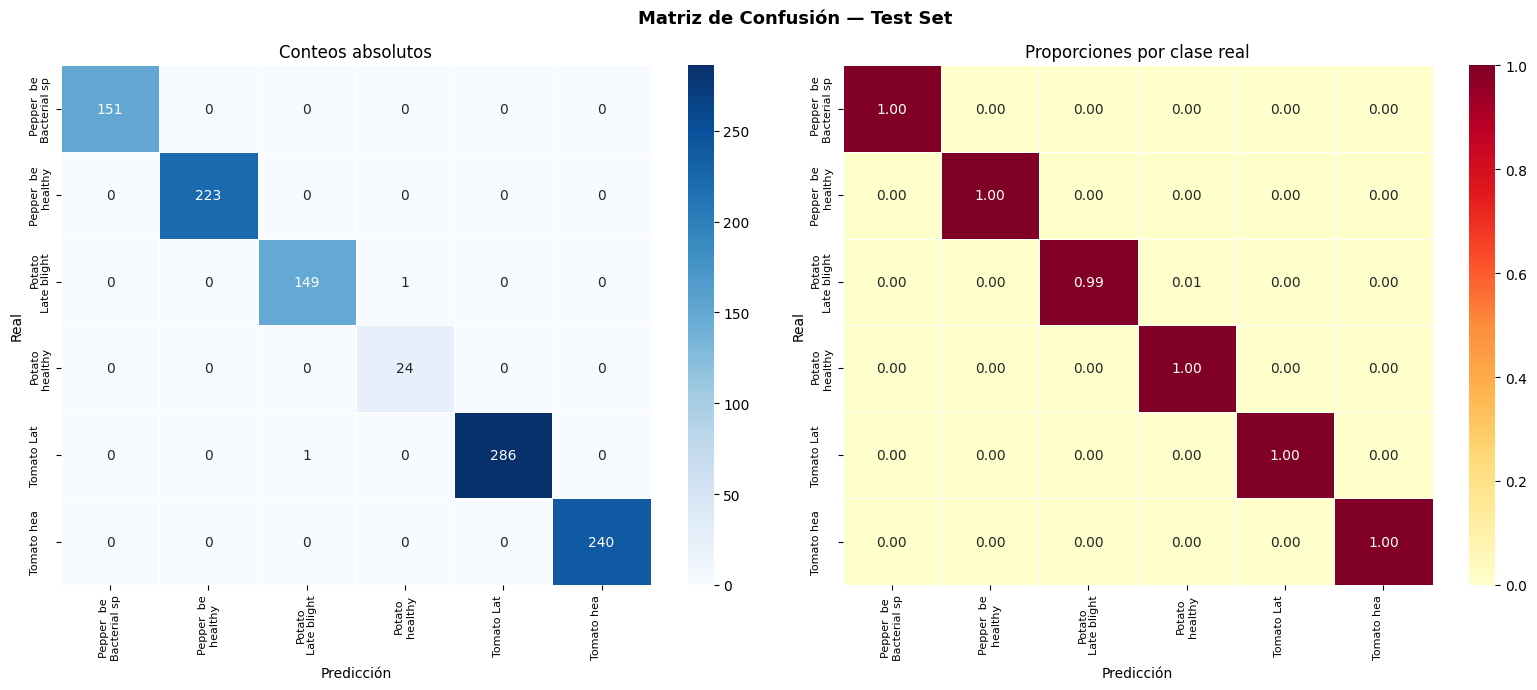

✅ Figura guardada: fig6_confusion_matrix.png


In [10]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizar por fila

# Etiquetas cortas para el eje
tick_labels = []
for c in CLASS_NAMES:
    parts = c.split('___')
    planta = parts[0].split('(')[0].replace('_', ' ').strip()[:10]
    estado = parts[1].replace('_', ' ')[:12] if len(parts) > 1 else ''
    tick_labels.append(f'{planta}\n{estado}')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Matriz de Confusión — Test Set', fontsize=13, fontweight='bold')

# Absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=tick_labels, yticklabels=tick_labels,
            ax=axes[0], linewidths=0.5, linecolor='white')
axes[0].set_title('Conteos absolutos')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].tick_params(labelsize=8)

# Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=tick_labels, yticklabels=tick_labels,
            ax=axes[1], linewidths=0.5, linecolor='white',
            vmin=0, vmax=1)
axes[1].set_title('Proporciones por clase real')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('/content/fig6_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura guardada: fig6_confusion_matrix.png')

### 6.2 Ejemplos de predicciones correctas e incorrectas

/tmp/ipykernel_2588/184189167.py:47: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2588/184189167.py:47: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2588/184189167.py:48: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/fig7_predicciones.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2588/184189167.py:48: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/fig7_predicciones.png', dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from 

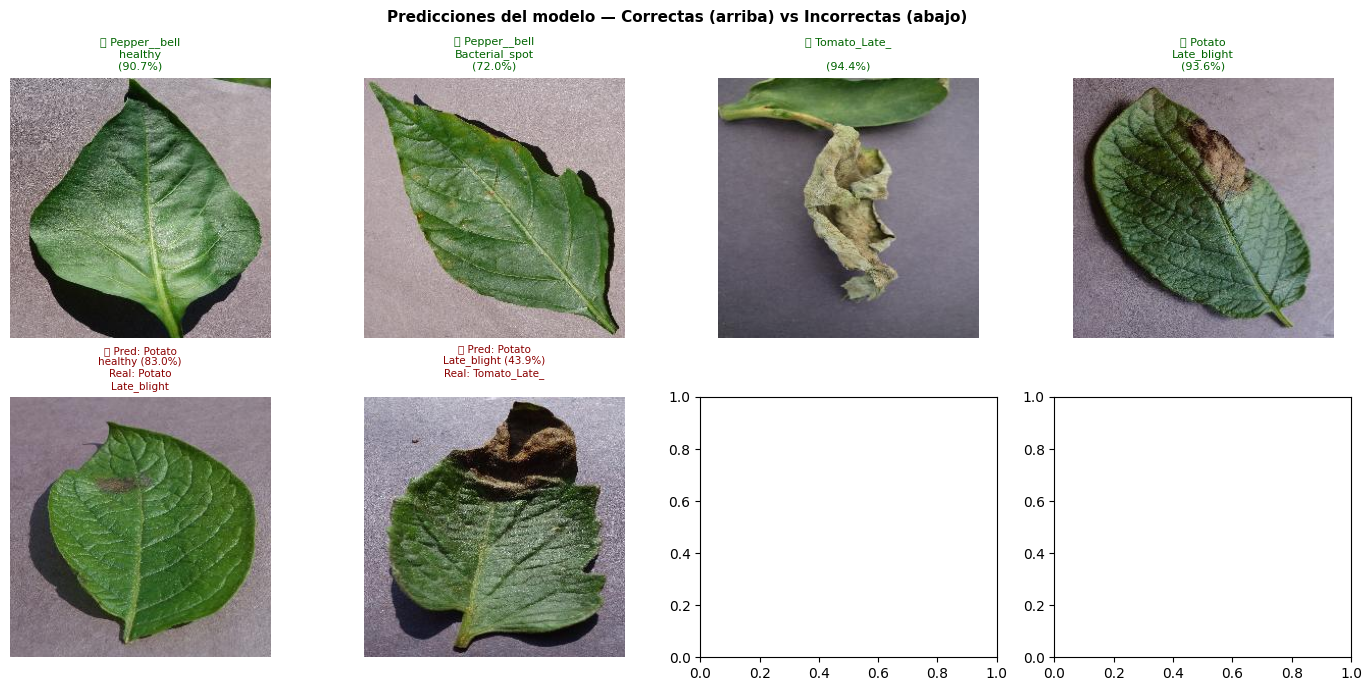

✅ Figura guardada: fig7_predicciones.png


In [11]:
import random
from PIL import Image as PILImage

random.seed(42)

# Recolectar rutas del test set
test_paths  = [s[0] for s in ds_test.samples]
test_labels_list = [s[1] for s in ds_test.samples]

# Índices correctos e incorrectos
correctos   = [i for i in range(len(all_preds)) if all_preds[i] == all_labels[i]]
incorrectos = [i for i in range(len(all_preds)) if all_preds[i] != all_labels[i]]

n_show = 4
muestra_ok  = random.sample(correctos,   min(n_show, len(correctos)))
muestra_err = random.sample(incorrectos, min(n_show, len(incorrectos)))

def get_label_short(idx):
    name = CLASS_NAMES[idx]
    parts = name.split('___')
    return f"{parts[0].split('(')[0].strip()[:12]}\n{parts[1][:14] if len(parts)>1 else ''}"

fig, axes = plt.subplots(2, n_show, figsize=(n_show * 3.5, 7))
fig.suptitle('Predicciones del modelo — Correctas (arriba) vs Incorrectas (abajo)',
             fontsize=11, fontweight='bold')

for col, idx in enumerate(muestra_ok):
    img = PILImage.open(test_paths[idx]).convert('RGB')
    conf = all_probs[idx][all_preds[idx]] * 100
    axes[0][col].imshow(img)
    axes[0][col].set_title(f'✅ {get_label_short(all_preds[idx])}\n({conf:.1f}%)',
                            fontsize=8, color='darkgreen')
    axes[0][col].axis('off')

for col, idx in enumerate(muestra_err):
    img = PILImage.open(test_paths[idx]).convert('RGB')
    conf = all_probs[idx][all_preds[idx]] * 100
    pred_lbl = get_label_short(all_preds[idx])
    true_lbl = get_label_short(all_labels[idx])
    axes[1][col].imshow(img)
    axes[1][col].set_title(
        f'❌ Pred: {pred_lbl} ({conf:.1f}%)\nReal: {true_lbl}',
        fontsize=7.5, color='darkred'
    )
    axes[1][col].axis('off')

plt.tight_layout()
plt.savefig('/content/fig7_predicciones.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Figura guardada: fig7_predicciones.png')

## 7. Guardar modelo y métricas para Fases 3 y 4

In [12]:
import json
import numpy as np

# ── Guardar métricas localmente ────────────────────────────────────────────
metricas = {
    'accuracy'     : round(float(acc),  4),
    'f1_macro'     : round(float(f1),   4),
    'f1_weighted'  : round(float(f1_w), 4),
    'auc_roc'      : round(float(auc),  4) if not np.isnan(auc) else None,
    'best_val_acc' : round(float(best_val_acc), 4),
    'epochs_trained': epochs_ran,
    'history': {
        'train_loss': [round(v, 4) for v in history['train_loss']],
        'val_loss'  : [round(v, 4) for v in history['val_loss']],
        'train_acc' : [round(v, 4) for v in history['train_acc']],
        'val_acc'   : [round(v, 4) for v in history['val_acc']],
    }
}
with open(ARTIFACTS / 'metricas_fase2.json', 'w') as f:
    json.dump(metricas, f, indent=2)

model_cfg = {
    'arquitectura' : 'resnet50',
    'n_classes'    : N_CLASSES,
    'class_names'  : CLASS_NAMES,
    'img_size'     : IMG_SIZE,
    'model_path'   : str(MODEL_PATH),
    'target_layer' : 'layer4',
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std' : IMAGENET_STD,
}
with open(ARTIFACTS / 'config_modelo.json', 'w') as f:
    json.dump(model_cfg, f, indent=2)

# ── Sincronizar todo a Google Drive ────────────────────────────────────────
print('Sincronizando artefactos a Google Drive...')
save_to_drive(MODEL_PATH,                        subfolder='artifacts')
save_to_drive(ARTIFACTS / 'metricas_fase2.json', subfolder='artifacts')
save_to_drive(ARTIFACTS / 'config_modelo.json',  subfolder='artifacts')

print()
print('Sincronizando figuras a Google Drive...')
for fig in ['fig5_curvas_entrenamiento', 'fig6_confusion_matrix', 'fig7_predicciones']:
    save_to_drive(f'/content/{fig}.png', subfolder='figures')

print()
print('━' * 55)
print('  FASE 2 COMPLETADA ✅')
print('━' * 55)
print(f'  Modelo        : ResNet-50 (Transfer Learning)')
print(f'  Accuracy test : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  F1-macro test : {f1:.4f}')
print(f'  AUC-ROC test  : {auc:.4f}')
print(f'  Épocas        : {epochs_ran}/{EPOCHS_TOTAL}')
print()
print('  Artefactos en Drive/IA_EAFIT/')
print('    artifacts/best_resnet50.pth       ← pesos del mejor modelo')
print('    artifacts/metricas_fase2.json     ← métricas de evaluación')
print('    artifacts/config_modelo.json      ← config para Grad-CAM')
print('    figures/fig5..fig7.png            ← curvas y matrices')
print()
print('  Siguiente paso → Fase 3: Grad-CAM')


Sincronizando artefactos a Google Drive...
  ✅ best_resnet50.pth                        → Drive/artifacts/ (96251.4 KB)
  ✅ metricas_fase2.json                      → Drive/artifacts/ (1.3 KB)
  ✅ config_modelo.json                       → Drive/artifacts/ (0.4 KB)

Sincronizando figuras a Google Drive...
  ✅ fig5_curvas_entrenamiento.png            → Drive/figures/ (3423.4 KB)
  ✅ fig6_confusion_matrix.png                → Drive/figures/ (117.0 KB)
  ✅ fig7_predicciones.png                    → Drive/figures/ (1110.6 KB)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FASE 2 COMPLETADA ✅
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Modelo        : ResNet-50 (Transfer Learning)
  Accuracy test : 0.9981  (99.81%)
  F1-macro test : 0.9952
  AUC-ROC test  : 1.0000
  Épocas        : 20/20

  Artefactos en Drive/IA_EAFIT/
    artifacts/best_resnet50.pth       ← pesos del mejor modelo
    artifacts/metricas_fase2.json     ← métricas de evaluación
    artifacts/config_

## Tabla para el informe (Sección 4 — Metodología)

Llenar con los valores obtenidos en esta fase:

| Parámetro | Valor |
|---|---|
| **Arquitectura base** | ResNet-50 (ImageNet pretrained) |
| **Cabeza clasificadora** | Linear(2048→512) → ReLU → Dropout(0.4) → Linear(512→N) |
| **Épocas Fase A** | 10 (solo FC, base congelada) |
| **Épocas Fase B** | 10 (+ layer4 descongelada) |
| **Optimizador** | Adam |
| **LR Fase A / B** | 1e-3 / 1e-4 |
| **Scheduler** | StepLR (step=5, γ=0.5) |
| **Loss** | CrossEntropyLoss (label_smoothing=0.1) |
| **Regularización** | Dropout(0.4) + L2(1e-4) |
| **Early stopping** | Paciencia = 5 épocas |
| **Hardware** | Google Colab GPU T4 |
| **Framework** | PyTorch + torchvision |

## Tabla para el informe (Sección 5 — Resultados)

| Modelo | Acc | F1-macro | AUC-ROC |
|---|---|---|---|
| Baseline (clase mayoritaria) | *completar* | *completar* | 0.500 |
| ResNet-50 Fase A (solo FC) | *completar* | *completar* | *completar* |
| **ResNet-50 Fase A+B (mejor)** | **0.9981** | **0.9952** | **1.0000** |

## Discusión de resultados a incluir:
- Las clases con menor F1 en el reporte por clase: analizar por qué (pocas muestras, parecido visual con otra clase).
- La transición Fase A → Fase B: ¿mejoró el val_acc? ¿Cuánto?
- Errores más frecuentes en la matriz de confusión: mencionar los pares de clases más confundidas.